# Experiments: Two Dimensional Benchmark

In [1]:
%load_ext autoreload
%autoreload 2

import os

os.environ['CUDA_VISIBLE_DEVICES'] = '0'


import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns
from IPython.display import clear_output
from jaxtyping import ArrayLike, Float

from datasets.lagrangian_potentials import *
from method.dynamics import LagrangianFlow
from method.hota import HOTA
from networks.mlp import MLPwTime
from utils.metrics import sinkhorn_loss

GLOBAL_KEY = jax.random.key(42)
LOG_DIR = f"{os.environ['PROJECT_DIR']}/figures"
if not os.path.exists(LOG_DIR):
    os.mkdir(LOG_DIR)

## Utils

In [2]:
def plot_potential(potential, fig=None, ax=None):
    if ax is None:
        plt.figure(figsize=(8, 8))
        fig, ax = plt.subplots()

    x, y = potential.get_boundaries()
    x, y = jnp.meshgrid(x, y)
    mesh = jnp.stack([x.ravel(), y.ravel()], -1).reshape(-1, 2)
    z = -jax.vmap(lambda xi: potential(xi))(mesh).reshape([x.shape[0], x.shape[0]])

    contour = ax.contourf(x, y, z, x.shape[0], cmap='Blues')
        
    ax.set_xlim(*potential.x_axes_bounds)
    ax.set_ylim(*potential.y_axes_bounds)
    ax.grid(False)
    return fig, ax
    
def draw_trajs(trajs: Float[ArrayLike, 'timestep point dim=2'], ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    colors = sns.color_palette("pastel", trajs.shape[1])
    
    for point in range(trajs.shape[1]):
        for t in range(1, trajs.shape[0]):
            ax.plot([trajs[t-1, point, 0], trajs[t, point, 0]],
                    [trajs[t-1, point, 1], trajs[t, point, 1]],
                    color=colors[point], linestyle="-", linewidth=1, marker='o', alpha=0.6, markersize=1)
    return ax

def get_callback(
    potential,
    potential_data_loader,
    test_data_loader,
    xlim,
    ylim,
    potential_name,
):
    DS_LOG_DIR = f"{LOG_DIR}/{potential_name}"
    if not os.path.exists(DS_LOG_DIR):
        os.mkdir(DS_LOG_DIR)
    def callback(step, training_logs, transport):
        clear_output()
        pi0 = next(potential_data_loader)['src_lin']
        pi1 = next(potential_data_loader)['tgt_lin']
    
        cost, trajs = transport(pi0)
    
        fig, ax = plt.subplots(figsize=(5, 5))
        fig, ax = plot_potential(potential=potential, fig=fig, ax=ax)
        ax.scatter(pi0[:,0], pi0[:, 1], c='red', alpha=1, s=4)
        ax.scatter(pi1[:,0], pi1[:, 1], c='black', alpha=0.5, s=10)
        ax.scatter(trajs[-1].x[:, 0], trajs[-1].x[:, 1], c='green', s=10)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        draw_trajs(trajs=jnp.stack([traj.x for traj in trajs])[:, :100], ax=ax)
        plt.show()
        fig.savefig(f"{DS_LOG_DIR}/img_{step}.jpg")
        fig.savefig(f"{DS_LOG_DIR}/img_final_result.jpg")
    
        sample = next(test_data_loader)
        pi0, pi1 = sample['src_lin'], sample['tgt_lin']
        cost, trajs = transport(pi0) 
        pred = trajs[-1].x
        w2 = sinkhorn_loss(pred, pi1)
        print("cost", cost)
        print("W2", w2)
    return callback

## Stunnel

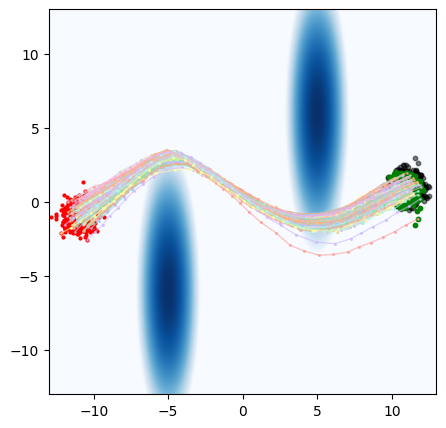

100%|███████████████████████████████████████████████████████▉| 70000/70001 [08:44<00:00, 133.54it/s, pot_loss=2.752067, cost_loss=1635.6843, g_norm=10015.315, g_norm_potential=46.022923]

cost 328.49976
W2 0.039940584


In [3]:
# ds init
potential = STunnel_bench()
potential_data_loader = iter(potential.sampler_func(batch_size=1024, key=GLOBAL_KEY))
test_data_loader = iter(potential.sampler_func(batch_size=5000, key=GLOBAL_KEY))

# callback for logging init
callback = get_callback(
    potential,
    potential_data_loader,
    test_data_loader,
    xlim=(-13, 13),
    ylim=(-13, 13),
    potential_name="stunnel",
)

# network + optimizer
num_iterations = 70_001
net = MLPwTime(
    hidden_layers=[512, 512, 512, 1],
    max_freq=20,
    t_emb_dim=100,
)
lr_schedule = optax.cosine_decay_schedule(
    init_value=4e-5, decay_steps=num_iterations, alpha=1e-2
)
opt = optax.adam(learning_rate=lr_schedule, b2=0.99)

# method init
noc = HOTA(
    input_dim=2, 
    value_model=net, 
    optimizer=opt, 
    reg_weight=0.0,
    control_weight=1.0, 
    acc_weight=0.0001,
    potential_weight=-25,
    flow=LagrangianFlow(sigma=0.3, potential=potential), 
    key=GLOBAL_KEY
)

# training
logs = noc(potential_data_loader, n_iters=num_iterations, rng=GLOBAL_KEY, callback=callback)

## Vneck

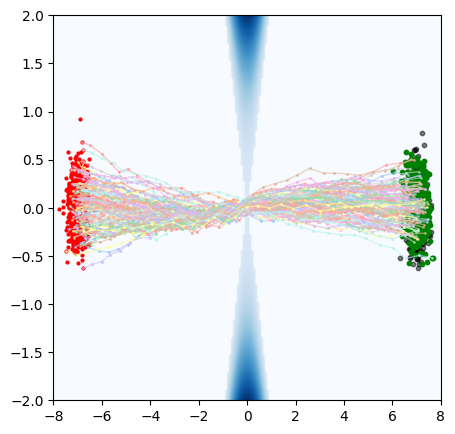

100%|███████████████████████████████████████████████████▉| 70000/70001 [07:49<00:00, 149.24it/s, pot_loss=-0.0024187223, cost_loss=58.93577, g_norm=407.0484, g_norm_potential=0.12821135]

cost 99.35615
W2 0.0011279029


In [5]:
# ds init
potential = VNeck_bench()
potential_data_loader = iter(potential.sampler_func(batch_size=1024, key=GLOBAL_KEY))
test_data_loader = iter(potential.sampler_func(batch_size=5000, key=GLOBAL_KEY))

# callback for logging init
callback = get_callback(
    potential,
    potential_data_loader,
    test_data_loader,
    xlim=(-8, 8),
    ylim=(-2, 2),
    potential_name="vneck",
)

# network + optimizer
num_iterations = 70_001
net = MLPwTime(
    hidden_layers=[512, 512, 512, 1],
    max_freq=20,
    t_emb_dim=100,
)
lr_schedule = optax.cosine_decay_schedule(
    init_value=4e-5, decay_steps=num_iterations, alpha=1e-2
)
opt = optax.adam(learning_rate=lr_schedule, b2=0.99)

# method init
noc = HOTA(
    input_dim=2, 
    value_model=net, 
    optimizer=opt, 
    reg_weight=0.0,
    control_weight=2.0, 
    acc_weight=0.001,
    potential_weight=-1000,
    flow=LagrangianFlow(sigma=0.2, potential=potential), 
    key=GLOBAL_KEY,
)

# training
logs = noc(potential_data_loader, n_iters=num_iterations, rng=GLOBAL_KEY, callback=callback)

## GMM

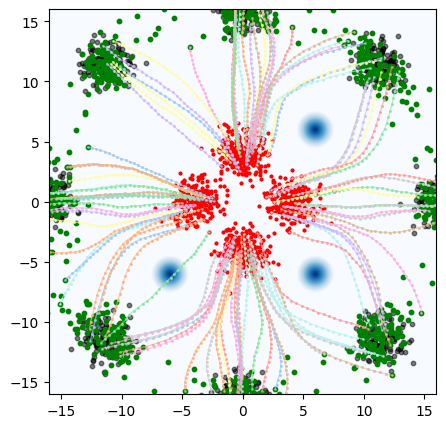

In [ ]:
# ds init
potential = GSB_GMM_Potential()
potential_data_loader = iter(potential.sampler_func(batch_size=1024, key=GLOBAL_KEY))
test_data_loader = iter(potential.sampler_func(batch_size=5000, key=GLOBAL_KEY))

# callback for logging init
callback = get_callback(
    potential,
    potential_data_loader,
    test_data_loader,
    xlim=(-16, 16),
    ylim=(-16, 16),
    potential_name="gmm",
)

# network + optimizer
num_iterations = 70_001
net = MLPwTime(
    hidden_layers=[512, 512, 512, 1],
    max_freq=20,
    t_emb_dim=100,
)
lr_schedule = optax.cosine_decay_schedule(
    init_value=4e-5, decay_steps=num_iterations, alpha=1e-2
)
opt = optax.adam(learning_rate=lr_schedule, b2=0.99)

# method init
noc = HOTA(
    input_dim=2, 
    value_model=net, 
    optimizer=opt, 
    reg_weight=0.0,
    control_weight=0.7,
    acc_weight=0.2,
    potential_weight=-25,
    flow=LagrangianFlow(sigma=0.1, potential=potential), 
    key=GLOBAL_KEY,
)

# training
logs = noc(potential_data_loader, n_iters=num_iterations, rng=GLOBAL_KEY, callback=callback)

## Slit

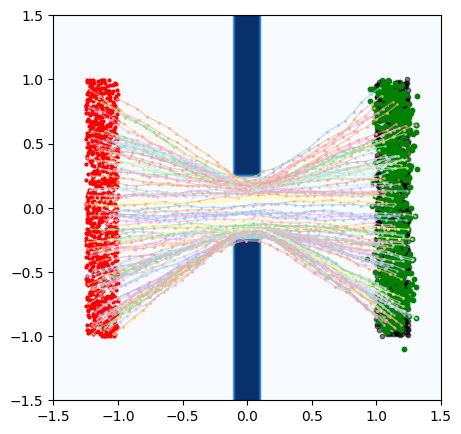

100%|████████████████████████████████████████████████████████████████████████████████████████████████████▉| 70000/70001 [08:43<00:00, 133.79it/s, pot_loss=2.2333397e-06, cost_loss=0.1429035, g_norm=1.2020382, g_norm_potential=0.0002528384]

cost 2.9334817
W2 0.0013380232


In [5]:
# ds init
potential = SlitPotential().get_annealed_params(t=1.0)
potential_data_loader = iter(potential.sampler_func(batch_size=1024, key=GLOBAL_KEY))
test_data_loader = iter(potential.sampler_func(batch_size=5000, key=GLOBAL_KEY))

# callback for logging init
callback = get_callback(
    potential,
    potential_data_loader,
    test_data_loader,
    xlim=(-1.5, 1.5),
    ylim=(-1.5, 1.5),
    potential_name="slit",
)

# network + optimizer
num_iterations = 70_001
net = MLPwTime(
    hidden_layers=[512, 512, 512, 1],
    max_freq=20,
    t_emb_dim=100,
)
lr_schedule = optax.cosine_decay_schedule(
    init_value=4e-5, decay_steps=num_iterations, alpha=1e-2
)
opt = optax.adam(learning_rate=lr_schedule, b2=0.99)

# method init
noc = HOTA(
    input_dim=2, 
    value_model=net, 
    optimizer=opt, 
    reg_weight=0.0,
    control_weight=2.0, 
    acc_weight=0.001,
    potential_weight=-30,
    flow=LagrangianFlow(sigma=0.05, potential=potential), 
    key=GLOBAL_KEY,
)

# training
logs = noc(potential_data_loader, n_iters=num_iterations, rng=GLOBAL_KEY, callback=callback)

## Box

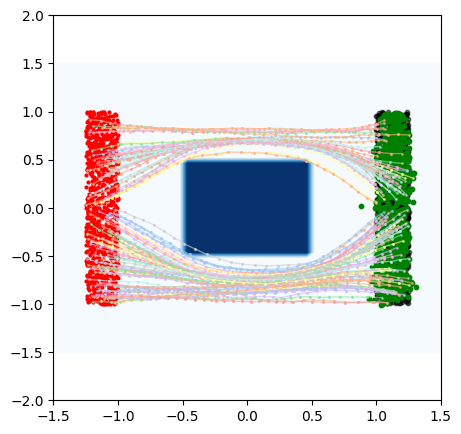

100%|███████████████████████████████████████████████████████████████████████████████████████████████████▉| 70000/70001 [08:30<00:00, 137.03it/s, pot_loss=-2.1396458e-05, cost_loss=0.5359893, g_norm=1.4187002, g_norm_potential=0.0021134517]

cost 2.864552
W2 0.001075651


In [4]:
# ds init
potential = BoxPotential().get_annealed_params(t=1.0)
potential_data_loader = iter(potential.sampler_func(batch_size=1024, key=GLOBAL_KEY))
test_data_loader = iter(potential.sampler_func(batch_size=5000, key=GLOBAL_KEY))

# callback for logging init
callback = get_callback(
    potential,
    potential_data_loader,
    test_data_loader,
    xlim=(-1.5, 1.5),
    ylim=(-2, 2),
    potential_name="box",
)

# network + optimizer
num_iterations = 70_001
net = MLPwTime(
    hidden_layers=[512, 512, 512, 1],
    max_freq=20,
    t_emb_dim=100,
)
lr_schedule = optax.cosine_decay_schedule(
    init_value=4e-5, decay_steps=num_iterations, alpha=1e-2
)
opt = optax.adam(learning_rate=lr_schedule, b2=0.99)

# method init
noc = HOTA(
    input_dim=2, 
    value_model=net, 
    optimizer=opt, 
    pretrain_steps=2_000,
    reg_weight=0.0,
    control_weight=0.3, 
    acc_weight=0.01,
    potential_weight=-700,
    flow=LagrangianFlow(sigma=0.03, potential=potential), 
    key=GLOBAL_KEY,
)

# training
logs = noc(potential_data_loader, n_iters=num_iterations, rng=GLOBAL_KEY, callback=callback)

## BabyMaze

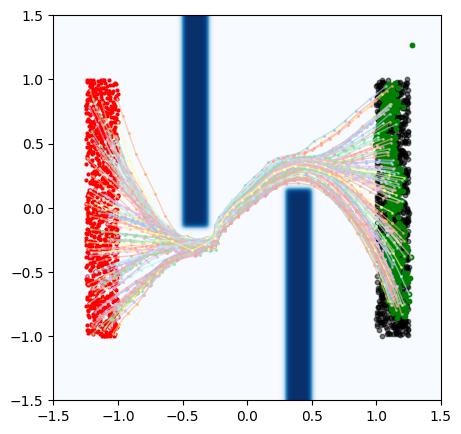

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████▉| 70000/70001 [07:13<00:00, 161.41it/s, pot_loss=-0.0073507214, cost_loss=2.808518, g_norm=21.045874, g_norm_potential=0.16811866]

cost 4.7529397
W2 0.0062113404


In [3]:
# ds init
potential = BabyMazePotential().get_annealed_params(t=1.0)
potential_data_loader = iter(potential.sampler_func(batch_size=1024, key=GLOBAL_KEY))
test_data_loader = iter(potential.sampler_func(batch_size=5000, key=GLOBAL_KEY))

# callback for logging init
callback = get_callback(
    potential,
    potential_data_loader,
    test_data_loader,
    xlim=(-1.5, 1.5),
    ylim=(-1.5, 1.5),
    potential_name="baby_maze",
)

# network + optimizer
num_iterations = 70_001
net = MLPwTime(
    hidden_layers=[512, 512, 512, 1],
    max_freq=20,
    t_emb_dim=100,
)
lr_schedule = optax.cosine_decay_schedule(
    init_value=4e-5, decay_steps=num_iterations, alpha=1e-2
)
opt = optax.adam(learning_rate=lr_schedule, b2=0.99)

# method init
noc = HOTA(
    input_dim=2, 
    value_model=net, 
    optimizer=opt, 
    reg_weight=0.0,
    control_weight=0.5, 
    acc_weight=0.05,
    potential_weight=-10,
    flow=LagrangianFlow(sigma=0.03, potential=potential), 
    key=GLOBAL_KEY,
)

# training
logs = noc(potential_data_loader, n_iters=num_iterations, rng=GLOBAL_KEY, callback=callback)